# Experiment-level ablation for coordination-age prediction

This notebook quantifies the accuracy retained when complete experiments are removed from the finalized 32-predictor aggregate model.

**Primary procedure:** RBF kernel ridge regression (KRR), outer LOOCV on the historical 115-subject train set, and five-fold inner hyperparameter tuning. The six removable groups are Box and Blocks, Jebsen–Taylor, finger pressing, reach-to-grasp, lift-object light, and lift-object heavy. Sex remains in every model.

The analysis has two parts:

1. evaluate every single-experiment omission; and
2. construct a greedy backward-elimination path using train-set OOF RMSE only.

The full train-selected path is frozen before test outcomes are loaded. Test performance is then reported for the full model, every single omission, and every subset on the selected backward path.

## Reproducibility and analysis contract

- Input: finalized aggregate `Data/X.csv` and `Data/y.csv`; no all-trials data.
- Domain validity: the aggregate data already enforce the minimum-five-valid-trials rule.
- Selection metric: pooled train-set OOF RMSE. AIC is not used because it is not naturally defined for the complete tuned RBF-KRR pipeline.
- Statistical preprocessing and KRR hyperparameters are learned within each applicable training fold.
- Each subset is cached immediately, allowing interrupted runs to resume.
- Test RMSE, MAE, and $R^2$ are descriptive external-performance results and never determine the elimination path.

In [1]:
from __future__ import annotations

import hashlib
import json
import os
from pathlib import Path
import sys
import time
from tempfile import TemporaryDirectory
from datetime import datetime, timezone
import warnings

os.environ.setdefault('MPLCONFIGDIR', '/private/tmp/coordination_age_mpl')
warnings.filterwarnings('ignore', message='pkg_resources is deprecated as an API.*')

from IPython.display import display
from joblib import Memory
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut

SEED = 42
INNER_FOLDS = 5
N_JOBS = 6
ID_COLUMN = 'SubjectNumber'
TARGET_COLUMN = 'AgeInYears'
SEX_COLUMN = 'Sex_0Female_1Male'
np.random.seed(SEED)


def find_project_root(start: Path) -> Path:
    candidates = []
    for parent in (start.resolve(), *start.resolve().parents):
        candidates.extend([parent, parent / 'coordination_age'])
    for candidate in candidates:
        if (
            (candidate / 'Data' / 'X.csv').exists()
            and (candidate / 'src' / 'krr_pipeline.py').exists()
        ):
            return candidate
    raise FileNotFoundError('Could not locate the coordination_age project root.')


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.krr_pipeline import make_krr_spec
from scripts.fit_jackknife_plus_krr import fit_tuned_krr

OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'task_ablation'
CACHE_DIR = OUTPUT_DIR / 'subset_cache'
FIGURE_DIR = OUTPUT_DIR / 'figures'
for directory in (OUTPUT_DIR, CACHE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


X_PATH = PROJECT_ROOT / 'Data' / 'X.csv'
Y_PATH = PROJECT_ROOT / 'Data' / 'y.csv'
SPLIT_PATH = PROJECT_ROOT / 'Data' / 'train_test_split.csv'
METADATA_PATH = PROJECT_ROOT / 'Data' / 'modeling_input_metadata.json'

X = pd.read_csv(X_PATH)
metadata = json.loads(METADATA_PATH.read_text())
subject_order = pd.Index(metadata['subject_order'], name=ID_COLUMN)
X.index = subject_order

split_table = pd.read_csv(SPLIT_PATH)
train_split = split_table.query("partition == 'train'").sort_values('partition_position')
test_split = split_table.query("partition == 'test'").sort_values('partition_position')
train_ids = pd.Index(train_split[ID_COLUMN].astype(int), name=ID_COLUMN)
test_ids = pd.Index(test_split[ID_COLUMN].astype(int), name=ID_COLUMN)

assert X.shape == (144, 32)
assert len(train_ids) == 115 and len(test_ids) == 29
assert train_ids.intersection(test_ids).empty
assert set(train_ids).union(test_ids) == set(subject_order)

X_train = X.loc[train_ids].copy()
X_test = X.loc[test_ids].copy()

# Expose only the training rows to model/subset selection, then discard the
# full target table. Test rows are not used until after the path freezes.
target_table = pd.read_csv(Y_PATH)
target_table.index = subject_order
y_train = target_table.loc[train_ids, TARGET_COLUMN].copy()
del target_table

print(f'Project root: {PROJECT_ROOT}')
display(pd.DataFrame([
    {'partition': 'train', 'subjects': len(X_train), 'features': X_train.shape[1],
     'missing_cells': int(X_train.isna().sum().sum())},
    {'partition': 'test predictors only', 'subjects': len(X_test), 'features': X_test.shape[1],
     'missing_cells': int(X_test.isna().sum().sum())},
]))

Project root: /Users/noamchowers/Documents/University/Lab Seminar/coordination_age


,partition,subjects,features,missing_cells
0,train,115,32,99
1,test predictors only,29,32,39


## Prespecified experiment groups

Each retained task-derived predictor belongs to exactly one group. The six groups plus sex must exhaust the frozen 32-column schema.

In [2]:
GROUPS = {
    'Box and Blocks': [
        'boxAndBlocks',
    ],
    'Jebsen-Taylor': [
        'jebsen_PageTurning', 'jebsen_SmallObjects', 'jebsen_Beans',
        'jebsen_Checkers', 'jebsen_LightCans', 'jebsen_HeavyCans',
    ],
    'Finger pressing': [
        'MVC', 'deltaV', 'V_UCM', 'V_ORT',
    ],
    'Reach-to-grasp': [
        'peakvel', 'movementtime', 'maxaperturePercent', 'meandistance',
    ],
    'Lift-object light': [
        'peakGripForceLight', 'peakLoadForceLight',
        'peakGripForceRateLight', 'peakLoadForceRateLight',
        'T1T3Light', 'T1T5Light', 'liftMeanDifferencesLight', 'numPeaksLight',
    ],
    'Lift-object heavy': [
        'peakGripForceHeavy', 'peakLoadForceHeavy',
        'peakGripForceRateHeavy', 'peakLoadForceRateHeavy',
        'T1T3Heavy', 'T1T5Heavy', 'liftMeanDifferencesHeavy', 'numPeaksHeavy',
    ],
}
GROUP_ORDER = tuple(GROUPS)

grouped_features = [feature for group in GROUP_ORDER for feature in GROUPS[group]]
assert len(grouped_features) == 31
assert len(set(grouped_features)) == 31
assert set(grouped_features) | {SEX_COLUMN} == set(X.columns)
assert not (set(grouped_features) & {SEX_COLUMN})


def features_for(retained_groups: tuple[str, ...]) -> list[str]:
    retained = set(retained_groups)
    return [
        column for column in X.columns
        if column == SEX_COLUMN
        or any(column in GROUPS[group] for group in retained)
    ]


def subset_id(retained_groups: tuple[str, ...]) -> str:
    retained = set(retained_groups)
    return 'groups_' + ''.join('1' if group in retained else '0' for group in GROUP_ORDER)


group_table = pd.DataFrame([
    {'experiment': group, 'n_features': len(features), 'features': ', '.join(features)}
    for group, features in GROUPS.items()
])
display(group_table)
print('Full subset ID:', subset_id(GROUP_ORDER))

,experiment,n_features,features
0,Box and Blocks,1,boxAndBlocks
1,Jebsen-Taylor,6,"jebsen_PageTurning, jebsen_SmallObjects, jebse..."
2,Finger pressing,4,"MVC, deltaV, V_UCM, V_ORT"
3,Reach-to-grasp,4,"peakvel, movementtime, maxaperturePercent, mea..."
4,Lift-object light,8,"peakGripForceLight, peakLoadForceLight, peakGr..."
5,Lift-object heavy,8,"peakGripForceHeavy, peakLoadForceHeavy, peakGr..."


Full subset ID: groups_111111


## Restartable nested-LOOCV runner

For every subset and outer fold, the KRR ridge penalty and RBF bandwidth are selected by five-fold inner CV. The selected pipeline is refitted on the complete outer training fold and predicts the left-out participant. Cache validation uses the source-data hashes, feature set, KRR grid, and CV settings.

In [3]:
RUN_SIGNATURE_PAYLOAD = {
    'x_sha256': sha256_file(X_PATH),
    'y_sha256': sha256_file(Y_PATH),
    'split_sha256': sha256_file(SPLIT_PATH),
    'seed': SEED,
    'inner_folds': INNER_FOLDS,
    'n_train': len(X_train),
    'scoring': 'neg_mean_squared_error',
    'krr_grid': {
        'alpha': np.logspace(-4, 3, 15).tolist(),
        'gamma': [0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0],
    },
}
RUN_SIGNATURE = hashlib.sha256(
    json.dumps(RUN_SIGNATURE_PAYLOAD, sort_keys=True).encode()
).hexdigest()


def regression_metrics(y_true, y_pred) -> dict[str, float]:
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
        'bias_age_minus_prediction': float(np.mean(np.asarray(y_true) - np.asarray(y_pred))),
    }


def cache_paths(key: str) -> dict[str, Path]:
    return {
        'summary': CACHE_DIR / f'{key}_summary.json',
        'oof': CACHE_DIR / f'{key}_oof.csv',
        'selections': CACHE_DIR / f'{key}_outer_selections.csv',
    }


def load_cached_subset(retained_groups: tuple[str, ...]):
    key = subset_id(retained_groups)
    paths = cache_paths(key)
    if not all(path.exists() for path in paths.values()):
        return None
    summary = json.loads(paths['summary'].read_text())
    if summary.get('run_signature') != RUN_SIGNATURE:
        return None
    if summary.get('features') != features_for(retained_groups):
        return None
    oof = pd.read_csv(paths['oof'])
    selections = pd.read_csv(paths['selections'])
    if len(oof) != len(X_train) or len(selections) != len(X_train):
        return None
    return summary, oof, selections


def run_nested_krr(retained_groups: tuple[str, ...], progress_every: int = 25):
    retained_groups = tuple(group for group in GROUP_ORDER if group in set(retained_groups))
    cached = load_cached_subset(retained_groups)
    if cached is not None:
        print(f'{subset_id(retained_groups)}: loaded cached result')
        return cached

    key = subset_id(retained_groups)
    features = features_for(retained_groups)
    X_subset = X_train[features]
    spec = make_krr_spec(features, sex_column=SEX_COLUMN)
    loo = LeaveOneOut()
    oof_records = []
    selection_records = []
    started = time.perf_counter()

    print(f'{key}: fitting {len(features)} predictors; retained={list(retained_groups)}')
    for outer_fold, (fit_idx, held_idx) in enumerate(loo.split(X_subset), start=1):
        fold_started = time.perf_counter()
        with TemporaryDirectory(prefix=f'task_ablation_{key}_') as cache_dir:
            fitted, params, inner_rmse, _ = fit_tuned_krr(
                X_subset.iloc[fit_idx],
                y_train.iloc[fit_idx],
                spec=spec,
                seed=SEED,
                inner_folds=INNER_FOLDS,
                n_jobs=N_JOBS,
                memory=Memory(cache_dir, verbose=0),
            )
        position = int(held_idx[0])
        prediction = float(np.asarray(fitted.predict(X_subset.iloc[held_idx])).ravel()[0])
        observed = float(y_train.iloc[position])
        oof_records.append({
            ID_COLUMN: int(X_subset.index[position]),
            'observed_age': observed,
            'oof_prediction': prediction,
            'residual_age_minus_prediction': observed - prediction,
        })
        selection_records.append({
            'outer_fold': outer_fold,
            ID_COLUMN: int(X_subset.index[position]),
            'inner_cv_rmse': inner_rmse,
            'alpha': params['model__regressor__alpha'],
            'gamma': params['model__regressor__gamma'],
            'fit_seconds': time.perf_counter() - fold_started,
        })
        if outer_fold == 1 or outer_fold % progress_every == 0 or outer_fold == len(X_subset):
            print(f'  fold {outer_fold:3d}/{len(X_subset)}')

    oof = pd.DataFrame(oof_records)
    selections = pd.DataFrame(selection_records)
    assert oof[ID_COLUMN].tolist() == X_subset.index.astype(int).tolist()
    metrics = regression_metrics(oof['observed_age'], oof['oof_prediction'])
    summary = {
        'run_signature': RUN_SIGNATURE,
        'subset_id': key,
        'retained_groups': list(retained_groups),
        'omitted_groups': [group for group in GROUP_ORDER if group not in retained_groups],
        'n_experiments': len(retained_groups),
        'n_predictors': len(features),
        'features': features,
        'train_oof_rmse': metrics['rmse'],
        'train_oof_mae': metrics['mae'],
        'train_oof_r2': metrics['r2'],
        'train_oof_bias_age_minus_prediction': metrics['bias_age_minus_prediction'],
        'fit_seconds': time.perf_counter() - started,
    }

    paths = cache_paths(key)
    oof.assign(subset_id=key).to_csv(paths['oof'], index=False)
    selections.assign(subset_id=key).to_csv(paths['selections'], index=False)
    paths['summary'].write_text(json.dumps(summary, indent=2, sort_keys=True))
    print(f"  complete: RMSE={summary['train_oof_rmse']:.4f}, "
          f"MAE={summary['train_oof_mae']:.4f}, R2={summary['train_oof_r2']:.4f}, "
          f"time={summary['fit_seconds'] / 60:.1f} min")
    return summary, oof, selections

## Stage A — leave one experiment out

Run the all experiments and all six single omissions. These same fits provide the first step of backward elimination.

In [4]:
full_groups = GROUP_ORDER
stage_a_subsets = [full_groups] + [
    tuple(group for group in GROUP_ORDER if group != omitted)
    for omitted in GROUP_ORDER
]

results = {}
for retained_groups in stage_a_subsets:
    summary, oof, selections = run_nested_krr(retained_groups)
    results[summary['subset_id']] = {
        'groups': retained_groups,
        'summary': summary,
        'oof': oof,
        'selections': selections,
    }

full_rmse = results[subset_id(full_groups)]['summary']['train_oof_rmse']
stage_a_train = pd.DataFrame([
    {
        **item['summary'],
        'omitted_experiment': (
            'None (all experiments)'
            if len(item['summary']['omitted_groups']) == 0
            else item['summary']['omitted_groups'][0]
        ),
        'delta_train_oof_rmse': item['summary']['train_oof_rmse'] - full_rmse,
    }
    for item in results.values()
])
display(stage_a_train[[
    'omitted_experiment', 'n_predictors', 'train_oof_rmse',
    'delta_train_oof_rmse', 'train_oof_mae', 'train_oof_r2', 'fit_seconds'
]].sort_values('train_oof_rmse').round(4))

groups_111111: loaded cached result
groups_011111: loaded cached result
groups_101111: loaded cached result
groups_110111: loaded cached result
groups_111011: loaded cached result
groups_111101: loaded cached result
groups_111110: loaded cached result


,omitted_experiment,n_predictors,train_oof_rmse,delta_train_oof_rmse,train_oof_mae,train_oof_r2,fit_seconds
1,Box and Blocks,31,1.4134,-0.0081,1.1296,0.8713,104.6476
0,None (all experiments),32,1.4215,0.0000,1.1222,0.8699,104.1103
4,Reach-to-grasp,28,1.4836,0.0621,1.1893,0.8582,110.3881
2,Jebsen-Taylor,26,1.4856,0.0641,1.1809,0.8579,106.8027
5,Lift-object light,24,1.5076,0.0861,1.2110,0.8536,109.7231
6,Lift-object heavy,24,1.5175,0.0960,1.1788,0.8517,113.3068
3,Finger pressing,28,1.5293,0.1078,1.2415,0.8494,110.5512


## Stage B — greedy backward elimination

At each step, remove the experiment whose removal yields the lowest train-set OOF RMSE. This is a greedy path, not an exhaustive search. Nonselected candidates are retained for audit.

In [5]:
current_groups = full_groups
path_records = [{
    **results[subset_id(current_groups)]['summary'],
    'step': 0,
    'removed_at_step': None,
}]
candidate_records = []
step = 0

while len(current_groups) > 1:
    step += 1
    step_candidates = []
    for removed_group in current_groups:
        candidate_groups = tuple(group for group in current_groups if group != removed_group)
        summary, oof, selections = run_nested_krr(candidate_groups)
        results[summary['subset_id']] = {
            'groups': candidate_groups,
            'summary': summary,
            'oof': oof,
            'selections': selections,
        }
        record = {
            **summary,
            'step': step,
            'parent_subset_id': subset_id(current_groups),
            'candidate_removed_group': removed_group,
        }
        step_candidates.append(record)

    winner = min(step_candidates, key=lambda row: (row['train_oof_rmse'], row['subset_id']))
    for record in step_candidates:
        record['selected_at_step'] = record['subset_id'] == winner['subset_id']
        candidate_records.append(record)

    current_groups = tuple(winner['retained_groups'])
    path_records.append({
        **winner,
        'removed_at_step': winner['candidate_removed_group'],
    })
    print(
        f"Step {step}: removed {winner['candidate_removed_group']}; "
        f"retained={list(current_groups)}; RMSE={winner['train_oof_rmse']:.4f}"
    )

candidate_table = pd.DataFrame(candidate_records)
path_table = pd.DataFrame(path_records)
candidate_table.to_csv(OUTPUT_DIR / 'backward_elimination_candidates.csv', index=False)
path_table.to_csv(OUTPUT_DIR / 'backward_elimination_path.csv', index=False)

# Freeze the data-selected path before test outcomes are loaded.
path_manifest = {
    'created_utc': datetime.now(timezone.utc).isoformat(),
    'run_signature': RUN_SIGNATURE,
    'selection_metric': 'train_oof_rmse',
    'group_order': list(GROUP_ORDER),
    'path': [
        {
            'step': int(row['step']),
            'subset_id': row['subset_id'],
            'retained_groups': row['retained_groups'],
            'removed_at_step': row.get('removed_at_step'),
            'train_oof_rmse': float(row['train_oof_rmse']),
        }
        for row in path_records
    ],
}
manifest_path = OUTPUT_DIR / 'train_selected_backward_path.json'
manifest_path.write_text(json.dumps(path_manifest, indent=2, sort_keys=True))
(OUTPUT_DIR / 'train_selected_backward_path.sha256').write_text(
    sha256_file(manifest_path) + '  ' + manifest_path.name + '\n'
)

display(path_table[[
    'n_experiments', 'retained_groups', 'removed_at_step', 'n_predictors',
    'train_oof_rmse', 'train_oof_mae', 'train_oof_r2'
]].round(4))
print('Frozen path:', manifest_path)
print('SHA-256:', sha256_file(manifest_path))

groups_011111: loaded cached result
groups_101111: loaded cached result
groups_110111: loaded cached result
groups_111011: loaded cached result
groups_111101: loaded cached result
groups_111110: loaded cached result
Step 1: removed Box and Blocks; retained=['Jebsen-Taylor', 'Finger pressing', 'Reach-to-grasp', 'Lift-object light', 'Lift-object heavy']; RMSE=1.4134
groups_001111: loaded cached result
groups_010111: loaded cached result
groups_011011: loaded cached result
groups_011101: loaded cached result
groups_011110: loaded cached result
Step 2: removed Reach-to-grasp; retained=['Jebsen-Taylor', 'Finger pressing', 'Lift-object light', 'Lift-object heavy']; RMSE=1.4762
groups_001011: loaded cached result
groups_010011: loaded cached result
groups_011001: loaded cached result
groups_011010: loaded cached result
Step 3: removed Lift-object light; retained=['Jebsen-Taylor', 'Finger pressing', 'Lift-object heavy']; RMSE=1.6229
groups_001001: loaded cached result
groups_010001: loaded cac

,n_experiments,retained_groups,removed_at_step,n_predictors,train_oof_rmse,train_oof_mae,train_oof_r2
0,6,"[Box and Blocks, Jebsen-Taylor, Finger pressin...",None,32,1.4215,1.1222,0.8699
1,5,"[Jebsen-Taylor, Finger pressing, Reach-to-gras...",Box and Blocks,31,1.4134,1.1296,0.8713
2,4,"[Jebsen-Taylor, Finger pressing, Lift-object l...",Reach-to-grasp,27,1.4762,1.1950,0.8596
3,3,"[Jebsen-Taylor, Finger pressing, Lift-object h...",Lift-object light,19,1.6229,1.2996,0.8304
4,2,"[Jebsen-Taylor, Lift-object heavy]",Finger pressing,15,1.8261,1.4380,0.7852
5,1,[Jebsen-Taylor],Lift-object heavy,7,2.2199,1.7740,0.6826


Frozen path: /Users/noamchowers/Documents/University/Lab Seminar/coordination_age/outputs/task_ablation/train_selected_backward_path.json
SHA-256: 77f3e37a4d0897cce1a685d6702e1d159cb960dbdf0d066266b183cc74a50c14


## Held-out test evaluation

The train-selected backward path is now frozen. Test outcomes are loaded at this point only. We tune and refit KRR on all 115 training participants for the all experiments, every single omission, and every selected backward-path subset; none of the resulting test metrics can alter the path.

In [6]:
assert manifest_path.exists()
frozen_path_hash = sha256_file(manifest_path)

# First extraction and use of test outcomes by the analysis.
target_table = pd.read_csv(Y_PATH)
target_table.index = subject_order
y_test = target_table.loc[test_ids, TARGET_COLUMN].copy()
del target_table

evaluation_subset_ids = []
for groups in stage_a_subsets + [tuple(record['retained_groups']) for record in path_records]:
    key = subset_id(groups)
    if key not in evaluation_subset_ids:
        evaluation_subset_ids.append(key)

test_prediction_records = []
full_fit_records = []
for key in evaluation_subset_ids:
    item = results[key]
    retained_groups = tuple(item['groups'])
    features = features_for(retained_groups)
    spec = make_krr_spec(features, sex_column=SEX_COLUMN)
    started = time.perf_counter()
    with TemporaryDirectory(prefix=f'task_ablation_fullfit_{key}_') as cache_dir:
        fitted, params, inner_rmse, _ = fit_tuned_krr(
            X_train[features], y_train,
            spec=spec,
            seed=SEED,
            inner_folds=INNER_FOLDS,
            n_jobs=N_JOBS,
            memory=Memory(cache_dir, verbose=0),
        )
    predictions = np.asarray(fitted.predict(X_test[features]), dtype=float).ravel()
    metrics = regression_metrics(y_test, predictions)
    full_fit_records.append({
        'subset_id': key,
        'retained_groups': list(retained_groups),
        'n_experiments': len(retained_groups),
        'n_predictors': len(features),
        'full_train_inner_cv_rmse': inner_rmse,
        'full_train_alpha': params['model__regressor__alpha'],
        'full_train_gamma': params['model__regressor__gamma'],
        'test_rmse': metrics['rmse'],
        'test_mae': metrics['mae'],
        'test_r2': metrics['r2'],
        'test_bias_age_minus_prediction': metrics['bias_age_minus_prediction'],
        'full_fit_seconds': time.perf_counter() - started,
    })
    test_prediction_records.extend([
        {
            'subset_id': key,
            ID_COLUMN: int(subject_id),
            'observed_age': float(observed),
            'test_prediction': float(prediction),
            'residual_age_minus_prediction': float(observed - prediction),
        }
        for subject_id, observed, prediction in zip(test_ids, y_test, predictions)
    ])
    print(f"{key}: test RMSE={metrics['rmse']:.4f}, MAE={metrics['mae']:.4f}, R2={metrics['r2']:.4f}")

full_fit_table = pd.DataFrame(full_fit_records)
test_predictions = pd.DataFrame(test_prediction_records)
test_predictions.to_csv(OUTPUT_DIR / 'task_subset_test_predictions.csv', index=False)
full_fit_table.to_csv(OUTPUT_DIR / 'task_subset_test_metrics.csv', index=False)

assert sha256_file(manifest_path) == frozen_path_hash
print(f'Frozen path unchanged after test evaluation: {frozen_path_hash}')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/lates

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


groups_111111: test RMSE=1.4035, MAE=1.1519, R2=0.8713


groups_011111: test RMSE=1.4345, MAE=1.1869, R2=0.8655


groups_101111: test RMSE=1.4939, MAE=1.3114, R2=0.8542


...

groups_111110: test RMSE=1.4697, MAE=1.2346, R2=0.8588


groups_011011: test RMSE=1.6239, MAE=1.3807, R2=0.8277


groups_011001: test RMSE=1.7189, MAE=1.4030, R2=0.8069


groups_010001: test RMSE=1.7989, MAE=1.4603, R2=0.7885


groups_010000: test RMSE=1.8933, MAE=1.4597, R2=0.7658
Frozen path unchanged after test evaluation: 77f3e37a4d0897cce1a685d6702e1d159cb960dbdf0d066266b183cc74a50c14


## Results

The first table answers the marginal leave-one-experiment-out question. The second reports the greedy burden–accuracy path. Test metrics are shown only after train-only selection was completed.

In [7]:
all_train_summaries = pd.DataFrame([
    item['summary'] for item in results.values()
])
all_metrics = all_train_summaries.merge(full_fit_table, on=[
    'subset_id', 'n_experiments', 'n_predictors'
], how='left', suffixes=('', '_fullfit'))
all_metrics['delta_train_oof_rmse'] = all_metrics['train_oof_rmse'] - full_rmse
full_test_rmse = float(full_fit_table.loc[
    full_fit_table['subset_id'] == subset_id(full_groups), 'test_rmse'
].iloc[0])
all_metrics['delta_test_rmse'] = all_metrics['test_rmse'] - full_test_rmse
all_metrics.to_csv(OUTPUT_DIR / 'task_subset_metrics.csv', index=False)

oof_long = pd.concat([
    item['oof'].assign(subset_id=key)
    for key, item in results.items()
], ignore_index=True)
outer_selections = pd.concat([
    item['selections'].assign(subset_id=key)
    for key, item in results.items()
], ignore_index=True)
oof_long.to_csv(OUTPUT_DIR / 'task_subset_oof_predictions.csv', index=False)
outer_selections.to_csv(
    OUTPUT_DIR / 'task_subset_outer_fold_hyperparameters.csv', index=False
)

stage_a_rows = []
for groups in stage_a_subsets:
    key = subset_id(groups)
    omitted = [group for group in GROUP_ORDER if group not in groups]
    row = all_metrics.loc[all_metrics['subset_id'] == key].iloc[0]
    stage_a_rows.append({
        'omitted_experiment': omitted[0] if omitted else 'None (all experiments)',
        'n_predictors': int(row['n_predictors']),
        'train_oof_rmse': row['train_oof_rmse'],
        'delta_train_oof_rmse': row['delta_train_oof_rmse'],
        'train_oof_mae': row['train_oof_mae'],
        'train_oof_r2': row['train_oof_r2'],
        'test_rmse': row['test_rmse'],
        'delta_test_rmse': row['delta_test_rmse'],
        'test_mae': row['test_mae'],
        'test_r2': row['test_r2'],
    })
stage_a_report = pd.DataFrame(stage_a_rows)
stage_a_report.to_csv(OUTPUT_DIR / 'leave_one_experiment_out_metrics.csv', index=False)

path_report = path_table[[
    'step', 'subset_id', 'n_experiments', 'retained_groups',
    'removed_at_step', 'n_predictors', 'train_oof_rmse',
    'train_oof_mae', 'train_oof_r2'
]].merge(
    full_fit_table[['subset_id', 'test_rmse', 'test_mae', 'test_r2']],
    on='subset_id', how='left'
)
path_report['delta_train_oof_rmse'] = path_report['train_oof_rmse'] - full_rmse
path_report['delta_test_rmse'] = path_report['test_rmse'] - full_test_rmse
path_report.to_csv(OUTPUT_DIR / 'backward_path_metrics.csv', index=False)

display(stage_a_report.round(4))
display(path_report[[
    'n_experiments', 'retained_groups', 'removed_at_step', 'n_predictors',
    'train_oof_rmse', 'delta_train_oof_rmse', 'test_rmse',
    'train_oof_mae', 'test_mae', 'train_oof_r2', 'test_r2'
]].round(4))

,omitted_experiment,n_predictors,train_oof_rmse,delta_train_oof_rmse,train_oof_mae,train_oof_r2,test_rmse,delta_test_rmse,test_mae,test_r2
0,None (all experiments),32,1.4215,0.0000,1.1222,0.8699,1.4035,0.0000,1.1519,0.8713
1,Box and Blocks,31,1.4134,-0.0081,1.1296,0.8713,1.4345,0.0311,1.1869,0.8655
2,Jebsen-Taylor,26,1.4856,0.0641,1.1809,0.8579,1.4939,0.0904,1.3114,0.8542
3,Finger pressing,28,1.5293,0.1078,1.2415,0.8494,1.5360,0.1326,1.2761,0.8458
4,Reach-to-grasp,28,1.4836,0.0621,1.1893,0.8582,1.6238,0.2204,1.3376,0.8277
5,Lift-object light,24,1.5076,0.0861,1.2110,0.8536,1.4841,0.0807,1.2064,0.8561
6,Lift-object heavy,24,1.5175,0.0960,1.1788,0.8517,1.4697,0.0662,1.2346,0.8588


,n_experiments,retained_groups,removed_at_step,n_predictors,train_oof_rmse,delta_train_oof_rmse,test_rmse,train_oof_mae,test_mae,train_oof_r2,test_r2
0,6,"[Box and Blocks, Jebsen-Taylor, Finger pressin...",None,32,1.4215,0.0000,1.4035,1.1222,1.1519,0.8699,0.8713
1,5,"[Jebsen-Taylor, Finger pressing, Reach-to-gras...",Box and Blocks,31,1.4134,-0.0081,1.4345,1.1296,1.1869,0.8713,0.8655
2,4,"[Jebsen-Taylor, Finger pressing, Lift-object l...",Reach-to-grasp,27,1.4762,0.0547,1.6239,1.1950,1.3807,0.8596,0.8277
3,3,"[Jebsen-Taylor, Finger pressing, Lift-object h...",Lift-object light,19,1.6229,0.2014,1.7189,1.2996,1.4030,0.8304,0.8069
4,2,"[Jebsen-Taylor, Lift-object heavy]",Finger pressing,15,1.8261,0.4046,1.7989,1.4380,1.4603,0.7852,0.7885
5,1,[Jebsen-Taylor],Lift-object heavy,7,2.2199,0.7984,1.8933,1.7740,1.4597,0.6826,0.7658


### Paired uncertainty for single omissions

For each single omission, resample the 115 aligned OOF prediction pairs and calculate the change in RMSE relative to the all experiments. These intervals summarize subject-level variability in the saved OOF errors; they do not account for the adaptive subset-selection process.

In [8]:
BOOTSTRAP_REPS = 10_000
rng = np.random.default_rng(SEED)
full_key = subset_id(full_groups)
full_oof = results[full_key]['oof'].set_index(ID_COLUMN).loc[train_ids]
bootstrap_indices = rng.integers(0, len(train_ids), size=(BOOTSTRAP_REPS, len(train_ids)))

uncertainty_rows = []
for groups in stage_a_subsets[1:]:
    key = subset_id(groups)
    candidate_oof = results[key]['oof'].set_index(ID_COLUMN).loc[train_ids]
    full_sq = np.square(
        full_oof['observed_age'].to_numpy() - full_oof['oof_prediction'].to_numpy()
    )
    candidate_sq = np.square(
        candidate_oof['observed_age'].to_numpy() - candidate_oof['oof_prediction'].to_numpy()
    )
    bootstrap_delta = (
        np.sqrt(candidate_sq[bootstrap_indices].mean(axis=1))
        - np.sqrt(full_sq[bootstrap_indices].mean(axis=1))
    )
    omitted = [group for group in GROUP_ORDER if group not in groups][0]
    uncertainty_rows.append({
        'omitted_experiment': omitted,
        'delta_train_oof_rmse': float(np.sqrt(candidate_sq.mean()) - np.sqrt(full_sq.mean())),
        'paired_bootstrap_q025': float(np.quantile(bootstrap_delta, 0.025)),
        'paired_bootstrap_q975': float(np.quantile(bootstrap_delta, 0.975)),
        'probability_rmse_increase': float(np.mean(bootstrap_delta > 0)),
        'bootstrap_reps': BOOTSTRAP_REPS,
    })

uncertainty_table = pd.DataFrame(uncertainty_rows).sort_values('delta_train_oof_rmse')
uncertainty_table.to_csv(
    OUTPUT_DIR / 'leave_one_experiment_out_paired_oof_bootstrap.csv', index=False
)
display(uncertainty_table.round(4))

,omitted_experiment,delta_train_oof_rmse,paired_bootstrap_q025,paired_bootstrap_q975,probability_rmse_increase,bootstrap_reps
0,Box and Blocks,-0.0081,-0.0979,0.0710,0.4558,10000
3,Reach-to-grasp,0.0621,-0.0414,0.1623,0.8822,10000
1,Jebsen-Taylor,0.0641,-0.0627,0.1836,0.8398,10000
4,Lift-object light,0.0861,-0.0298,0.1987,0.9274,10000
5,Lift-object heavy,0.0960,-0.0229,0.2101,0.9490,10000
2,Finger pressing,0.1078,-0.0092,0.2188,0.9642,10000


## Visual summaries

The left panel shows the change from the all experiments after each single omission. The right panel shows absolute RMSE along the train-selected greedy path. Test performance is descriptive and did not determine the path.

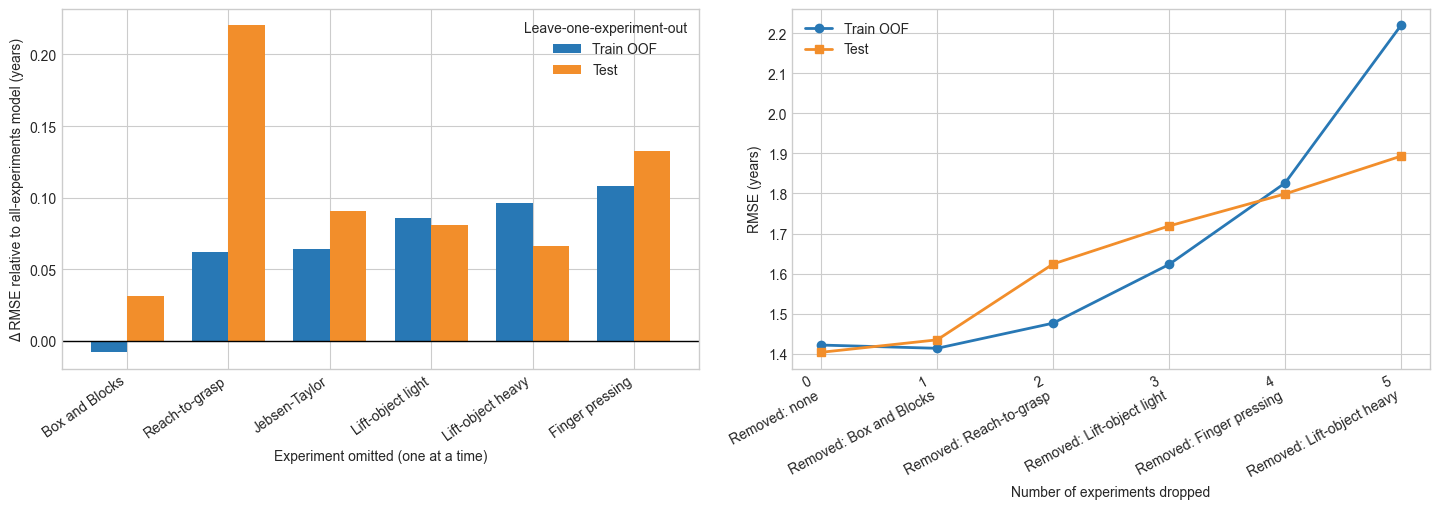

Saved: /Users/noamchowers/Documents/University/Lab Seminar/coordination_age/outputs/task_ablation/figures/task_ablation_rmse.png


In [9]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))

# Stage A: each bar compares one omitted experiment with the all-experiments baseline.
leave_one_plot = stage_a_report.query(
    "omitted_experiment != 'None (all experiments)'"
).copy().sort_values('delta_train_oof_rmse')
x = np.arange(len(leave_one_plot))
width = 0.36
axes[0].bar(
    x - width / 2, leave_one_plot['delta_train_oof_rmse'], width,
    label='Train OOF', color='#2878B5'
)
axes[0].bar(
    x + width / 2, leave_one_plot['delta_test_rmse'], width,
    label='Test', color='#F28E2B'
)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(leave_one_plot['omitted_experiment'], rotation=35, ha='right')
axes[0].set_ylabel('Δ RMSE relative to all-experiments model (years)')
axes[0].set_xlabel('Experiment omitted (one at a time)')
axes[0].legend(title='Leave-one-experiment-out', frameon=False)

# Stage B: step 0 is all experiments; each subsequent point adds one omission.
path_plot = path_report.sort_values('step').copy()
axes[1].plot(
    path_plot['step'], path_plot['train_oof_rmse'],
    marker='o', linewidth=2, label='Train OOF', color='#2878B5'
)
axes[1].plot(
    path_plot['step'], path_plot['test_rmse'],
    marker='s', linewidth=2, label='Test', color='#F28E2B'
)
step_labels = [
    '0\nRemoved: none' if row.step == 0
    else f'{int(row.step)}\nRemoved: {row.removed_at_step}'
    for row in path_plot.itertuples(index=False)
]
axes[1].set_xticks(path_plot['step'])
axes[1].set_xticklabels(step_labels, rotation=28, ha='right')
axes[1].set_xlabel('Number of experiments dropped')
axes[1].set_ylabel('RMSE (years)')
axes[1].legend(frameon=False)

fig.tight_layout()
figure_path = FIGURE_DIR / 'task_ablation_rmse.png'
fig.savefig(figure_path, dpi=220, bbox_inches='tight')
plt.show()
print('Saved:', figure_path)


## Headline results and cautions

The cell below reports the selected elimination order and the best single omission according to train-set OOF RMSE. Close RMSE values should be interpreted practically rather than as proof of equivalence. The greedy path need not contain the globally optimal subset at every number of retained experiments, and its selected OOF errors are development estimates.

In [10]:
best_single = stage_a_report.query(
    "omitted_experiment != 'None (all experiments)'"
).sort_values('train_oof_rmse').iloc[0]

print('Best single omission by train OOF RMSE:')
print(
    f"  {best_single['omitted_experiment']}: "
    f"train OOF RMSE={best_single['train_oof_rmse']:.4f} "
    f"(delta={best_single['delta_train_oof_rmse']:+.4f}); "
    f"test RMSE={best_single['test_rmse']:.4f} "
    f"(delta={best_single['delta_test_rmse']:+.4f})"
)

print('\nGreedy elimination order:')
for row in path_report.sort_values('step').itertuples(index=False):
    if row.step == 0:
        print(f'  {row.n_experiments} experiments: all experiments')
    else:
        print(
            f'  {row.n_experiments} experiments: removed {row.removed_at_step}; '
            f'train OOF RMSE={row.train_oof_rmse:.4f}; test RMSE={row.test_rmse:.4f}'
        )

print(f'\nAll artifacts: {OUTPUT_DIR}')

# Final reproducibility artifacts.
stage_a_ids = [subset_id(groups) for groups in stage_a_subsets]
path_ids = path_report['subset_id'].tolist()
test_predictions.query('subset_id in @stage_a_ids').to_csv(
    OUTPUT_DIR / 'leave_one_experiment_out_test_predictions.csv', index=False
)
test_predictions.query('subset_id in @path_ids').to_csv(
    OUTPUT_DIR / 'backward_path_test_predictions.csv', index=False
)

import platform
import sklearn

manifest_outputs = [
    'leave_one_experiment_out_metrics.csv',
    'leave_one_experiment_out_test_predictions.csv',
    'leave_one_experiment_out_paired_oof_bootstrap.csv',
    'backward_elimination_candidates.csv',
    'backward_elimination_path.csv',
    'backward_path_metrics.csv',
    'backward_path_test_predictions.csv',
    'task_subset_metrics.csv',
    'task_subset_oof_predictions.csv',
    'task_subset_outer_fold_hyperparameters.csv',
    'task_subset_test_metrics.csv',
    'task_subset_test_predictions.csv',
    'train_selected_backward_path.json',
    'train_selected_backward_path.sha256',
    'figures/task_ablation_rmse.png',
]
analysis_manifest = {
    'created_utc': datetime.now(timezone.utc).isoformat(),
    'analysis': 'experiment_level_task_ablation',
    'run_signature': RUN_SIGNATURE,
    'inputs': {
        'X.csv': sha256_file(X_PATH),
        'y.csv': sha256_file(Y_PATH),
        'train_test_split.csv': sha256_file(SPLIT_PATH),
    },
    'n_train': len(train_ids),
    'n_test': len(test_ids),
    'group_order': list(GROUP_ORDER),
    'groups': GROUPS,
    'always_retained': [SEX_COLUMN],
    'selection_metric': 'train_oof_rmse',
    'outer_cv': 'LeaveOneOut',
    'inner_folds': INNER_FOLDS,
    'seed': SEED,
    'n_jobs': N_JOBS,
    'krr_grid': RUN_SIGNATURE_PAYLOAD['krr_grid'],
    'evaluated_subset_count': len(results),
    'backward_path_sha256': frozen_path_hash,
    'software': {
        'python': platform.python_version(),
        'numpy': np.__version__,
        'pandas': pd.__version__,
        'scikit_learn': sklearn.__version__,
    },
    'outputs': {
        relative: {
            'sha256': sha256_file(OUTPUT_DIR / relative),
            'bytes': (OUTPUT_DIR / relative).stat().st_size,
        }
        for relative in manifest_outputs
    },
}
analysis_manifest_path = OUTPUT_DIR / 'task_subset_manifest.json'
analysis_manifest_path.write_text(
    json.dumps(analysis_manifest, indent=2, sort_keys=True)
)
print('Manifest:', analysis_manifest_path)


Best single omission by train OOF RMSE:
  Box and Blocks: train OOF RMSE=1.4134 (delta=-0.0081); test RMSE=1.4345 (delta=+0.0311)

Greedy elimination order:
  6 experiments: all experiments
  5 experiments: removed Box and Blocks; train OOF RMSE=1.4134; test RMSE=1.4345
  4 experiments: removed Reach-to-grasp; train OOF RMSE=1.4762; test RMSE=1.6239
  3 experiments: removed Lift-object light; train OOF RMSE=1.6229; test RMSE=1.7189
  2 experiments: removed Finger pressing; train OOF RMSE=1.8261; test RMSE=1.7989
  1 experiments: removed Lift-object heavy; train OOF RMSE=2.2199; test RMSE=1.8933

All artifacts: /Users/noamchowers/Documents/University/Lab Seminar/coordination_age/outputs/task_ablation
Manifest: /Users/noamchowers/Documents/University/Lab Seminar/coordination_age/outputs/task_ablation/task_subset_manifest.json
